# Консенсус: эксперименты на датасетах


В таблицах символ **—** в ячейках ARI/AMI/NMI/FMI означает, что у предсказанной разметки после 
отсечения шума (labels ≥ 0) либо меньше двух точек, либо только 1 кластер - тогда внешние метрики 
не считаются. 


In [16]:
import sys
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
from sklearn.metrics import (
    adjusted_rand_score,
    adjusted_mutual_info_score,
    normalized_mutual_info_score,
    fowlkes_mallows_score,
)

sys.path.insert(0, "..")
warnings.filterwarnings("ignore")

from consensus.runner import ConsensusRunner
from consensus.monti_helpers import builtin_fit_predict_callable
from consensus.fca2 import FCAConsensus as FCA2Consensus
from visualization.plots import plot_coassociation

from data_generator.uci_real import (
    load_iris_fc,
    load_wine_fc,
    load_ecoli_fc,
    load_seeds_fc,
    load_segment_fc,
)
from data_generator.habr_synthetic import all_habr_datasets

BASE_ALGORITHMS = ["dbscan", "hdbscan", "dpc", "rd_dac", "ckdpc"]
N_BOOTSTRAP = 20
ENSEMBLE_METHODS = ["coassoc", "voting"]


In [17]:
def k_max_for_n(n):
    return max(6, min(15, int(round(n ** 0.4))))


def metrics_vs_truth(y_true, labels):
    labels = np.asarray(labels, dtype=int)
    y_true = np.asarray(y_true, dtype=int)
    mask = labels >= 0
    if mask.sum() < 2 or len(np.unique(labels[mask])) < 2:
        return dict(ARI=np.nan, AMI=np.nan, NMI=np.nan, FMI=np.nan)
    yt = y_true[mask]
    lp = labels[mask]
    return dict(
        ARI=float(adjusted_rand_score(yt, lp)),
        AMI=float(adjusted_mutual_info_score(yt, lp)),
        NMI=float(normalized_mutual_info_score(yt, lp)),
        FMI=float(fowlkes_mallows_score(yt, lp)),
    )


def runner_kw(n_samples, rng_seed):
    return dict(
        n_bootstrap=N_BOOTSTRAP,
        p_sample=0.8,
        k_range=(2, k_max_for_n(n_samples)),
        random_state=rng_seed,
        verbose=False,
    )


def style_metrics(df, cols=("ARI", "AMI", "NMI", "FMI")):
    fmt = {c: "{:.4f}" for c in cols}
    fmt["k_found"] = "{:.0f}"
    fmt["sec"] = "{:.3f}"
    st = df.style.format(fmt, na_rep="—")
    st = st.background_gradient(subset=list(cols), cmap="RdYlGn", vmin=0.0, vmax=1.0)
    return st


def fca_ari_full_vs_half_rows(label_matrix, y_true, rng_seed=0):
    rng = np.random.default_rng(rng_seed)
    n_r = label_matrix.shape[0]
    k = max(2, n_r // 2)
    pick = np.sort(rng.choice(n_r, size=k, replace=False))
    f_full = FCAConsensus()
    f_full.fit_from_labels(label_matrix)
    f_sub = FCAConsensus()
    f_sub.fit_from_labels(label_matrix[pick])
    a_full = metrics_vs_truth(y_true, f_full.labels_)["ARI"]
    a_sub = metrics_vs_truth(y_true, f_sub.labels_)["ARI"]
    return a_full, a_sub, f_full.labels_

In [18]:
DATASETS = []

for loader in [
    load_iris_fc,
    load_wine_fc,
    load_ecoli_fc,
    load_seeds_fc,
    load_segment_fc,
]:
    ds = loader()
    DATASETS.append((ds.name, ds.X, ds.y_true))

for ds in all_habr_datasets():
    DATASETS.append((ds.name, ds.X, ds.y_true))

from data_generator.classic_shapes import load_sipu_shapes

for ds in load_sipu_shapes():
    DATASETS.append((ds.name, ds.X, ds.y_true))

EXPERIMENT_DIR = Path("../synthetic_datasets/experiment")
if EXPERIMENT_DIR.is_dir():
    for combo_dir in sorted([d for d in EXPERIMENT_DIR.iterdir() if d.is_dir()], key=lambda p: p.name):
        xf = combo_dir / "rep001_X.npy"
        rf = combo_dir / "rep001_rf.npy"
        if xf.is_file() and rf.is_file():
            Xg = np.load(xf)
            yg = np.load(rf).astype(int) - 1
            tag = "gen_" + combo_dir.name.replace(" ", "").replace("=", "")
            DATASETS.append((tag, Xg, yg))

print(len(DATASETS), "datasets")


34 datasets


In [15]:
rows_monti = []
rows_cohirf = []
rows_ensemble = []

for i, (name, X, y_true) in enumerate(DATASETS):
    X = np.asarray(X, dtype=float)
    y_true = np.asarray(y_true, dtype=int)
    n = X.shape[0]
    seed = 42 + i
    kw = runner_kw(n, seed)
    print(f"[{i+1}/{len(DATASETS)}] {name}  n={n}  m={X.shape[1]}")

    for b in BASE_ALGORITHMS:
        fp = builtin_fit_predict_callable(b, X, y_true)
        t0 = time.perf_counter()
        r_m = ConsensusRunner(
            algorithm_names=[],
            consensus_methods=["monti2"],
            monti2_base_callable=fp,
            **kw,
        ).fit(X, y_true=y_true)
        sec_m = time.perf_counter() - t0
        if "monti2" in r_m.labels:
            m = metrics_vs_truth(y_true, r_m.labels["monti2"])
            rows_monti.append(
                dict(
                    dataset=name,
                    base=b,
                    k_found=r_m.k_found.get("monti2", np.nan),
                    sec=sec_m,
                    **m,
                )
            )

        t1 = time.perf_counter()
        r_c = ConsensusRunner(
            algorithm_names=[],
            consensus_methods=["cohirf", "cohirf_relaxed"],
            cohirf_base_callable=fp,
            **kw,
        ).fit(X, y_true=y_true)
        sec_c = time.perf_counter() - t1
        for key, mode in (("cohirf", "strict"), ("cohirf_relaxed", "relaxed")):
            if key not in r_c.labels:
                continue
            m = metrics_vs_truth(y_true, r_c.labels[key])
            rows_cohirf.append(
                dict(
                    dataset=name,
                    base=b,
                    mode=mode,
                    k_found=r_c.k_found.get(key, np.nan),
                    sec=r_c.runtime_sec.get(key, np.nan),
                    **m,
                )
            )

    t2 = time.perf_counter()
    r_e = ConsensusRunner(
        algorithm_names=BASE_ALGORITHMS,
        algorithm_params={},
        consensus_methods=ENSEMBLE_METHODS,
        **kw,
    ).fit(X, y_true=y_true)
    sec_e = time.perf_counter() - t2

    if r_e.label_matrix is not None:
        t_fca2 = time.perf_counter()
        try:
            _fca2 = FCA2Consensus()
            _fca2.fit_from_labels(r_e.label_matrix)
            _fca2_sec = time.perf_counter() - t_fca2
            _fca2_lbl = _fca2.labels_
            _fca2_k = int(len(np.unique(_fca2_lbl[_fca2_lbl >= 0])))
            _fca2_met = metrics_vs_truth(y_true, _fca2_lbl)
            rows_ensemble.append(dict(
                dataset=name, method="fca",
                k_found=_fca2_k, sec=_fca2_sec, **_fca2_met,
            ))
        except Exception as _fe:
            rows_ensemble.append(dict(
                dataset=name, method="fca",
                k_found=np.nan, sec=np.nan,
                ARI=np.nan, AMI=np.nan, NMI=np.nan, FMI=np.nan,
            ))

    for mth in ENSEMBLE_METHODS:
        if mth not in r_e.labels:
            rows_ensemble.append(
                dict(
                    dataset=name,
                    method=mth,
                    k_found=np.nan,
                    sec=np.nan,
                    ARI=np.nan,
                    AMI=np.nan,
                    NMI=np.nan,
                    FMI=np.nan,
                )
            )
            continue
        met = metrics_vs_truth(y_true, r_e.labels[mth])
        rows_ensemble.append(
            dict(
                dataset=name,
                method=mth,
                k_found=r_e.k_found.get(mth, np.nan),
                sec=r_e.runtime_sec.get(mth, np.nan),
                **met,
            )
        )
    rows_ensemble.append(
        dict(
            dataset=name,
            method="_pipeline_ensemble_",
            k_found=np.nan,
            sec=sec_e,
            ARI=np.nan,
            AMI=np.nan,
            NMI=np.nan,
            FMI=np.nan,
        )
    )

df_monti = pd.DataFrame(rows_monti)
df_cohirf = pd.DataFrame(rows_cohirf)
df_ens = pd.DataFrame(rows_ensemble)


[1/34] uci_iris  n=150  m=4


ModuleNotFoundError: No module named 'caspailleur'

In [5]:
display(style_metrics(df_monti.set_index(["dataset", "base"])))

In [ ]:
_mset = set(df_cohirf["mode"].unique())

display(style_metrics(df_cohirf[df_cohirf["mode"] == "strict"].set_index(["dataset", "base"])))
display(style_metrics(df_cohirf[df_cohirf["mode"] == "relaxed"].set_index(["dataset", "base"])))
_p = df_cohirf.pivot_table(index=["dataset", "base"], columns="mode", values="ARI", aggfunc="first")
_p = _p.copy()
_p["ARI_relaxed_minus_strict"] = _p["relaxed"] - _p["strict"]
display(
    _p.style.format("{:.4f}", na_rep="—").background_gradient(
        subset=["ARI_relaxed_minus_strict"],
        cmap="coolwarm",
        vmin=-0.5,
        vmax=0.5,
    )
)

In [7]:
df_e = df_ens[df_ens["method"] != "_pipeline_ensemble_"].copy()
display(style_metrics(df_e.set_index(["dataset", "method"])))

## FCA через библиотеку caspailleur

Переработанная реализация FCAConsensus использует caspailleur.api.mine_concepts вместо ручного построения решётки понятий.  

In [1]:
import sys, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import (
    adjusted_rand_score, adjusted_mutual_info_score,
    normalized_mutual_info_score, fowlkes_mallows_score,
)

sys.path.insert(0, "..")
warnings.filterwarnings("ignore")

from consensus.runner import ConsensusRunner
from consensus.fca import FCAConsensus

BASE_ALGORITHMS = ["dbscan", "hdbscan", "dpc", "rd_dac", "ckdpc"]
N_BOOTSTRAP = 20


def k_max_for_n(n):
    return max(6, min(15, int(round(n ** 0.4))))


def metrics_vs_truth(y_true, labels):
    labels = np.asarray(labels, dtype=int)
    y_true = np.asarray(y_true, dtype=int)
    mask = labels >= 0
    if mask.sum() < 2 or len(np.unique(labels[mask])) < 2:
        return dict(ARI=np.nan, AMI=np.nan, NMI=np.nan, FMI=np.nan)
    yt, lp = y_true[mask], labels[mask]
    return dict(
        ARI=float(adjusted_rand_score(yt, lp)),
        AMI=float(adjusted_mutual_info_score(yt, lp)),
        NMI=float(normalized_mutual_info_score(yt, lp)),
        FMI=float(fowlkes_mallows_score(yt, lp)),
    )


def runner_kw(n_samples, rng_seed):
    return dict(
        n_bootstrap=N_BOOTSTRAP, p_sample=0.8,
        k_range=(2, k_max_for_n(n_samples)),
        random_state=rng_seed, verbose=False,
    )


def style_metrics(df, cols=("ARI", "AMI", "NMI", "FMI")):
    fmt = {c: "{:.4f}" for c in cols}
    fmt["k_found"] = "{:.0f}"
    fmt["sec"] = "{:.3f}"
    st = df.style.format(fmt, na_rep="—")
    return st.background_gradient(subset=list(cols), cmap="RdYlGn", vmin=0.0, vmax=1.0)


if "DATASETS" not in dir():
    from data_generator.uci_real import (
        load_iris_fc, load_wine_fc, load_ecoli_fc, load_seeds_fc, load_segment_fc,
    )
    from data_generator.habr_synthetic import all_habr_datasets
    from data_generator.classic_shapes import load_sipu_shapes

    DATASETS = []
    for loader in [load_iris_fc, load_wine_fc, load_ecoli_fc, load_seeds_fc, load_segment_fc]:
        ds = loader()
        DATASETS.append((ds.name, ds.X, ds.y_true))
    for ds in all_habr_datasets():
        DATASETS.append((ds.name, ds.X, ds.y_true))
    for ds in load_sipu_shapes():
        DATASETS.append((ds.name, ds.X, ds.y_true))
    EXPERIMENT_DIR = Path("../synthetic_datasets/experiment")
    if EXPERIMENT_DIR.is_dir():
        for combo_dir in sorted([d for d in EXPERIMENT_DIR.iterdir() if d.is_dir()], key=lambda p: p.name):
            xf, rf = combo_dir / "rep001_X.npy", combo_dir / "rep001_rf.npy"
            if xf.is_file() and rf.is_file():
                tag = "gen_" + combo_dir.name.replace(" ", "").replace("=", "")
                DATASETS.append((tag, np.load(xf), np.load(rf).astype(int) - 1))
    print(f"Загружено {len(DATASETS)} датасетов")

rows_fca_casp = []

for i, (name, X, y_true) in enumerate(DATASETS):
    X_arr = np.asarray(X, dtype=float)
    y_arr = np.asarray(y_true, dtype=int)
    n = X_arr.shape[0]
    seed = 42 + i
    kw = runner_kw(n, seed)
    print(f"[{i+1}/{len(DATASETS)}] {name}  n={n}  m={X_arr.shape[1]}", end="  ")

    t0 = time.perf_counter()
    try:
        r = ConsensusRunner(
            algorithm_names=BASE_ALGORITHMS,
            algorithm_params={},
            consensus_methods=["fca"],
            **kw,
        ).fit(X_arr, y_true=y_arr)
        sec = time.perf_counter() - t0

        if "fca" in r.labels:
            m = metrics_vs_truth(y_arr, r.labels["fca"])
            k = r.k_found.get("fca", np.nan)
            rows_fca_casp.append(dict(dataset=name, k_found=k, sec=sec, **m))
            print(f"k={int(k) if not np.isnan(k) else '?'}  ARI={m['ARI']:.4f}  sec={sec:.2f}s")
        else:
            rows_fca_casp.append(dict(dataset=name, k_found=np.nan, sec=np.nan,
                                      ARI=np.nan, AMI=np.nan, NMI=np.nan, FMI=np.nan))
            print("FCA не вернул результат")
    except Exception as exc:
        rows_fca_casp.append(dict(dataset=name, k_found=np.nan, sec=np.nan,
                                  ARI=np.nan, AMI=np.nan, NMI=np.nan, FMI=np.nan))
        print(f"ERROR: {exc}")

df_fca_casp = pd.DataFrame(rows_fca_casp).set_index("dataset")

Datasets: 34
[1/34] uci_iris  n=150
[2/34] uci_wine  n=178
[3/34] uci_ecoli  n=327
[4/34] uci_seeds  n=210
[5/34] uci_statlog_segment  n=2310
[6/34] habr_numpy_linear  n=150
[7/34] habr_numpy_timeseries  n=150
[8/34] habr_sklearn_blobs  n=300
[9/34] habr_sklearn_regression_style  n=150
[10/34] habr_scipy_mixed  n=150
[11/34] shape_flame  n=240
[12/34] shape_jain  n=373
[13/34] shape_spiral  n=312
[14/34] shape_aggregation  n=788
[15/34] shape_r15  n=600
[16/34] shape_d31  n=3100
[17/34] gen_V15_K7_alpha0.25  n=1000
[18/34] gen_V15_K7_alpha0.50  n=1000
[19/34] gen_V15_K7_alpha0.75  n=1000
[20/34] gen_V15_K15_alpha0.25  n=1000
[21/34] gen_V15_K15_alpha0.50  n=1000
[22/34] gen_V15_K15_alpha0.75  n=1000
[23/34] gen_V15_K21_alpha0.25  n=1000
[24/34] gen_V15_K21_alpha0.50  n=1000
[25/34] gen_V15_K21_alpha0.75  n=1000
[26/34] gen_V50_K7_alpha0.25  n=1000
[27/34] gen_V50_K7_alpha0.50  n=1000
[28/34] gen_V50_K7_alpha0.75  n=1000
[29/34] gen_V50_K15_alpha0.25  n=1000
[30/34] gen_V50_K15_alpha0.5

In [2]:
print(f"FCA (caspailleur): результаты по {len(df_fca_casp)} датасетам\n")
display(style_metrics(df_fca_casp))

FCA (caspailleur): результаты по 34 датасетам

dataset                                k     sec      ARI      AMI      NMI      FMI
------------------------------------------------------------------------------------
uci_iris                               6    0.48  0.5506  0.6475  0.6617  0.7357
uci_wine                              10    0.06  0.4078  0.4726  0.4948  0.5854
uci_ecoli                             14    0.11  0.6865  0.6080  0.6281  0.7752
uci_seeds                             11    0.07  0.7267  0.6498  0.6649  0.8121
uci_statlog_segment                   18    7.66  0.5850  0.7155  0.7188  0.6560
habr_numpy_linear                      9    0.04  0.6225  0.7296  0.7406  0.7425
habr_numpy_timeseries                 11    0.04  0.5393  0.6789  0.6943  0.6825
habr_sklearn_blobs                    12    0.06  0.8544  0.8381  0.8435  0.9024
habr_sklearn_regression_style         13    0.04  0.5152  0.6741  0.6927  0.6648
habr_scipy_mixed                       6    0.04  0.91

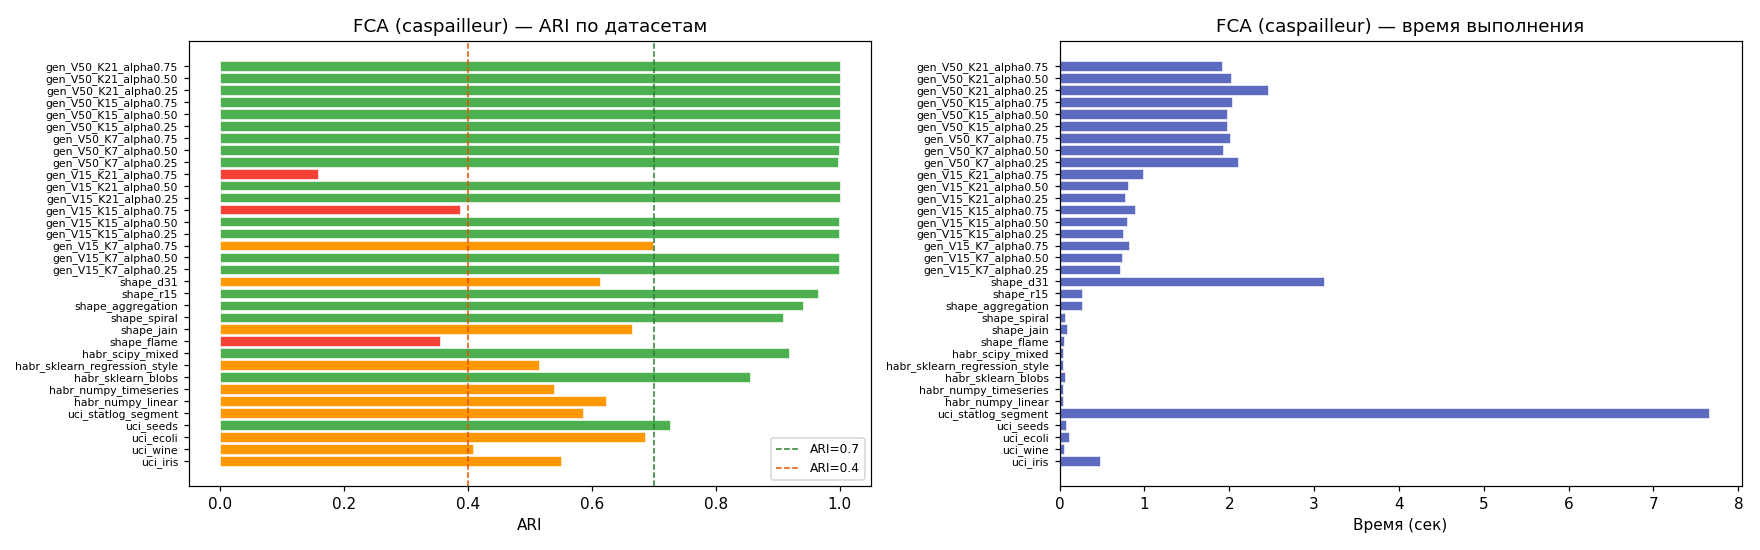

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ari_vals = df_fca_casp["ARI"].fillna(0)
colors = ["#4caf50" if v >= 0.7 else "#ff9800" if v >= 0.4 else "#f44336" for v in ari_vals]
axes[0].barh(df_fca_casp.index, ari_vals, color=colors, edgecolor="white", linewidth=0.4)
axes[0].axvline(0.7, color="#2e7d32", linestyle="--", linewidth=1, label="ARI=0.7 (хорошо)")
axes[0].axvline(0.4, color="#e65100", linestyle="--", linewidth=1, label="ARI=0.4 (приемлемо)")
axes[0].set_xlabel("ARI")
axes[0].set_title("FCA (caspailleur) — ARI по датасетам")
axes[0].legend(fontsize=8)
axes[0].set_xlim(-0.05, 1.05)
axes[0].tick_params(axis="y", labelsize=7)

sec_vals = df_fca_casp["sec"].fillna(0)
axes[1].barh(df_fca_casp.index, sec_vals, color="#5c6bc0", edgecolor="white", linewidth=0.4)
axes[1].set_xlabel("Время (сек)")
axes[1].set_title("FCA (caspailleur) — время выполнения")
axes[1].tick_params(axis="y", labelsize=7)

plt.tight_layout()
plt.show()

valid = df_fca_casp["ARI"].dropna()
print(f"\nСводка FCA (caspailleur):")
print(f"  Датасетов с результатом : {len(valid)} / {len(df_fca_casp)}")
print(f"  Среднее ARI             : {valid.mean():.4f}")
print(f"  Медиана ARI             : {valid.median():.4f}")
print(f"  ARI >= 0.7 (хорошо)     : {(valid >= 0.7).sum()} датасетов")
print(f"  ARI >= 0.4 (приемлемо)  : {(valid >= 0.4).sum()} датасетов")
print(f"  Среднее время           : {df_fca_casp['sec'].dropna().mean():.2f} сек")